# Selection Operators — Technical Overview

This notebook provides a comprehensive guide to MalthusJAX selection operators.

**What You'll Learn:**
- Static RNG budgeting and resource mapping
- Operator interface: atomic logic vs population-level slicing
- Elite preservation mechanism
- Building custom selection operators
- Performance considerations and selection pressure tuning

## Part 1: Selection Architecture Overview

Selection operators serve a critical role in genetic algorithms:

1. **Input**: Population (with fitness values) + PRNG keys
2. **Output**: Dual indices: parent indices for crossover/mutation, elite indices for preservation
3. **Key Innovation**: Static RNG budgeting ensures deterministic key allocation and predictable JIT compilation

The key insight is that selection uses **a single PRNG key for all selections** because JAX vectorizes sampling operations internally. This allows `num_keys_per_atomic_operation = 1` (not `pop_size × num_selections`), dramatically reducing PRNG overhead.

## Part 2: Static RNG Budgeting

Unlike crossover/mutation (which scale with population size), selection uses constant-time PRNG budgeting:

```
Key Budget Formula (Selection):
- num_keys_per_atomic_operation = 1 (for stochastic) or 0 (for deterministic)
- total_keys_needed = K  (shared across ALL selections via internal vectorization)

Contrast with Crossover/Mutation:
- total_keys_needed = num_pairs × num_offspring × K
- OR: num_mutations × num_offspring × K
```

**Why This Matters:**
- One-time host-side `jax.random.split()` (no dynamic allocations)
- Enables static shapes: `ResourceMap` knows exact key counts at initialization
- Minimizes host-device traffic
- JAX can fuse vectorized sampling operations into single kernel

## Part 3: Output Contract — Dual Indices

Selection returns **two separate index arrays**:

```python
parent_idx, elite_idx = selection(keys, population, config)
```

**parent_idx**: Shape `(num_selections,)`, dtype int32/int64
- Indices for parents (may have duplicates, e.g., high-fitness individual selected multiple times)
- Used downstream: `parents = jnp.take(population, parent_idx)` → gather parents
- Fed to crossover/mutation for offspring generation

**elite_idx**: Shape `(n_elites,)`, dtype int32/int64
- Indices of top-fitness individuals (no duplicates)
- Automatically sorted by fitness (highest first)
- Used for elite preservation: directly copied to next generation, bypassing crossover/mutation

**Design Benefit**: Returning indices (not reordered genomes) decouples selection logic from memory movement, enabling single gather operation and better XLA fusion.

## Part 4: Elite Preservation Mechanism

Elite preservation maintains the best individuals across generations:

**Three Key Steps:**

1. **Initialization**: `selection = selection.set_n_elites(n)` at engine startup
   - **IMPORTANT**: `set_n_elites()` is immutable—returns a new instance, must assign the result
   - Example: `selection = selection.set_n_elites(2)`

2. **Selection Returns Dual Output**: During evolution, selection returns both parent and elite indices
   - `parent_idx, elite_idx = selection(keys, population, config)`
   - Parents feed to crossover/mutation (may have duplicates)
   - Elites preserved directly (guaranteed top-k by fitness)

3. **Engine Integration**: Engine manages next generation
   - Creates offspring from parents via crossover/mutation
   - Preserves top individuals by inserting elite genomes directly
   - Result: Best `n_elites` individuals guaranteed in next generation

**Elite Index Properties**:
- Always highest-fitness individuals
- Sorted descending (elite_idx[0] = highest fitness individual)
- No duplicates (each elite selected exactly once)
- Guaranteed orthogonal to parent indices (elites not re-selected, preserved intact)

## Part 5: Built-in Selection Operators

MalthusJAX provides three production-ready selection operators:

### TournamentSelection
- **Strategy**: Randomly sample `tournament_size` candidates, select highest-fitness winner
- **Selection Pressure**: Tunable (tournament_size=2→3→7 increases pressure)
- **Fitness Range**: Works with any range (positive, negative, mixed)
- **Complexity**: O(num_selections × tournament_size)
- **When to Use**: General-purpose, unknown fitness ranges, diversity important

### RouletteSelection
- **Strategy**: Fitness-proportional selection via softmax transformation (temperature-controlled)
- **Selection Pressure**: Tunable via temperature parameter
- **Fitness Range**: **Non-negative only** (negative fitness → NaN in softmax)
- **Optimization**: Gumbel-Max trick when `num_selections == pop_size` (full replacement)
- **When to Use**: Well-characterized fitness landscapes, fitness-weighted selection desired

### ElitePoolSelection
- **Strategy**: Select parents uniformly from top `elite_k` individuals
- **Selection Pressure**: Very high (only elite_k contribute genes)
- **Fitness Range**: Works with any range
- **Optimization**: Fuses elite identification with parent selection (single O(N) argpartition)
- **When to Use**: Late optimization phase, fine-tuning, high exploitation needed

## Part 6: PRNG Format Handling

MalthusJAX supports both modern JAX PRNG (typed keys) and legacy formats:

**Key Format Detection:**
- `typed_keys=True` (modern): PRNG keys are scalar values, extract via `keys if keys.ndim == 0 else keys[0]`
- `typed_keys=False` (legacy): PRNG keys are uint32[2] pairs, extract via `keys if keys.ndim <= 1 else keys[0]`

**Engine Sets This at Initialization:**
- User provides a PRNG backend (e.g., `jax.random.default_rng()`)
- Engine detects format automatically via `get_prng_format()`
- All operators receive the `typed_keys` flag in their config

**Selection operators must handle both** to maintain backward compatibility without special user configuration.

## Part 7: Atomic Interface vs Population-Level Slicing

Selection operators have two layers:

**Tier 1: Atomic Logic (`_select()` method)**
- Pure function: `_select(keys, fitness, config) → indices`
- Operates on raw fitness array
- Returns selected indices with shape `(num_selections,)`
- Implementation-specific (tournament, softmax, argpartition, etc.)

**Tier 2: Population-Level (`BaseSelection.__call__()`)**
- Public API: accepts Population object OR raw fitness array
- Flexibility: `getattr(population, "fitness", population)` extracts fitness or uses array directly
- Dual output: calls `_select()` for parents, then `get_elite_indices()` for elites
- Returns tuple: `(parent_idx, elite_idx)`

**Design Benefit**: Decoupling allows selection logic to remain focused on fitness → indices mapping, while engine handles downstream population slicing.

## Part 8: Hardware-Specific Optimization

For multi-device deployments, `ShardingManager` defines named sharding specs:

**Key Concepts:**
- `pop_sharding`: Specifies how population is distributed across devices
- `vector_sharding`: Specifies layout for fitness arrays
- `device_put(selection_indices, pop_sharding)`: Places index buffer on correct devices

**Optimization Strategy:**
- Fitness arrays sharded consistently with population layout
- Selection index computation remains local (minimal cross-device moves)
- Downstream gather operations are device-local

**PRNG Distribution:**
- `split_key_sharded()`: Distributes RNG keys across mesh for per-device independent streams

## Part 9: Developer Checklist — Implementing Custom Selection

### Core Requirements
- [ ] Define `num_keys_per_atomic_operation` (0 for deterministic, ≥1 for stochastic)
- [ ] Implement `_select(keys, fitness, config) → indices` pure function
- [ ] Return integer `jnp.ndarray` shape `(num_selections,)`, dtype int32/int64
- [ ] Handle both PRNG formats (typed_keys=True/False)
- [ ] Verify `num_keys()` returns correct total (typically just 1)
- [ ] Document selection strategy, fitness requirements, use cases
- [ ] Add unit tests: correctness, shape contracts, both PRNG formats

### Optional Enhancements
- [ ] Override `get_elite_indices()` to fuse elite identification with parent selection (like ElitePoolSelection)
- [ ] Implement fast paths for common cases (e.g., early termination for small tournaments)
- [ ] Add visualization helpers for selection pressure analysis
- [ ] Document interaction with elitism (performance implications)

### Documentation
- [ ] Comprehensive docstring: strategy, parameters, fitness requirements, complexity
- [ ] When-to-use guidance (problem type, evolution phase)
- [ ] Example string specification format
- [ ] Cross-reference BaseSelection API
- [ ] Shape contracts for both parent_idx and elite_idx outputs

## Part 10: Performance Considerations

### Selection Pressure Tuning

**Early Phase** (high diversity needed):
- TournamentSelection: tournament_size=2 (mild exploitation)
- RouletteSelection: temperature=3.0 (uniform-ish)
- Elitism: 0 (let diverse population search broadly)

**Mid Phase** (balanced):
- TournamentSelection: tournament_size=3 (default, recommended)
- RouletteSelection: temperature=1.0 (fitness-proportional)
- Elitism: 1-2 (preserve best found so far)

**Late Phase** (fine-tuning):
- TournamentSelection: tournament_size=7 (high exploitation)
- ElitePoolSelection: elite_k=10% (even higher pressure)
- Elitism: 5-10% (preserve broad elite pool)

### Computational Complexity

| Operator | Without Elitism | With Elitism | Notes |
|----------|-----------------|--------------|-------|
| TournamentSelection | O(num_selections × tournament_size) | +O(N) argpartition | Separate elite pass |
| RouletteSelection | O(N + num_selections) or O(N log N) | +O(N) argpartition | Gumbel-Max only when num_selections==pop_size |
| ElitePoolSelection | O(N + num_selections) | O(N argpartition) single pass | **Best with elitism** (fused) |

### Elite Pool Fusion Optimization

ElitePoolSelection has a special advantage when elitism is enabled:
- **Without fusion** (Tournament, Roulette): Parent selection O(X) + elite identification O(N) = O(X + N)
- **With fusion** (ElitePoolSelection): Single `k = min(elite_k, n_elites)` argpartition = O(N)
- **Benefit**: Avoids second O(N) scan—particularly valuable for large populations

## Part 11: Next Steps

- **Integration**: Combine selection with crossover/mutation in engine loop
- **Customization**: Implement domain-specific selection (e.g., lexicographic ranking for multi-objective)
- **Analysis**: Track selection pressure over generations (measure diversity metrics)
- **Hybrid Approaches**: Alternate selection operators by evolution phase
- **Constraint Handling**: Extend selection to handle infeasible individuals (penalty-based ranking)

In [6]:
# Setup: Import required libraries

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

print("JAX version:", jax.__version__)
print("Available devices:", jax.devices())

# Setup: Enable 64-bit precision for numerical stability
jax.config.update("jax_enable_x64", True)

JAX version: 0.9.1
Available devices: [CpuDevice(id=0)]


In [7]:
# Example 1: TournamentSelection — Basic Usage
"""
Demonstrates TournamentSelection with different tournament sizes
to show how selection pressure changes.
"""

# Setup population
key = jr.PRNGKey(42)
pop_size = 10
num_selections = 4

# Fitness values (higher = better)
fitness = jnp.array(
    [1.0, 5.0, 3.0, 9.0, 2.0, 7.0, 4.0, 6.0, 8.0, 0.5]
)

print("Population Fitness:")
for i, f in enumerate(fitness):
    print(f"  Individual {i}: fitness = {f:.1f}")

# Note: In practice, would use:
# from malthusjax.operators.selection import TournamentSelection
# Here we simulate the behavior for illustration

def simulate_tournament_selection(
    key: jnp.ndarray,
    fitness: jnp.ndarray,
    num_selections: int,
    tournament_size: int,
    num_keys_per_atomic_op: int = 1,
) -> jnp.ndarray:
    """
    Simulate tournament selection.
    Returns parent indices of shape (num_selections,).
    """
    pop_size = len(fitness)
    num_keys = num_keys_per_atomic_op
    keys = jr.split(key, num_keys)
    rng = keys[0] if keys.ndim > 0 else keys

    # Generate tournament participants
    participants = jr.randint(
        rng, shape=(num_selections, tournament_size),
        minval=0, maxval=pop_size
    )

    # Get fitness of participants and select best (argmax)
    participant_fitness = jnp.take(fitness, participants)
    winners = jnp.argmax(participant_fitness, axis=1)

    # Map back to original indices
    parent_idx = jnp.take_along_axis(
        participants, winners[:, None], axis=1
    ).squeeze()

    return parent_idx

# Test with different tournament sizes
key_t2, key_t3, key_t5 = jr.split(key, 3)

print("\nTournament Size = 2 (mild exploitation):")
parents_t2 = simulate_tournament_selection(
    key_t2, fitness, num_selections, tournament_size=2
)
print(f"  Selected parent indices: {parents_t2}")
print(f"  Selected fitness values: {jnp.take(fitness, parents_t2)}")

print("\nTournament Size = 3 (balanced, default):")
parents_t3 = simulate_tournament_selection(
    key_t3, fitness, num_selections, tournament_size=3
)
print(f"  Selected parent indices: {parents_t3}")
print(f"  Selected fitness values: {jnp.take(fitness, parents_t3)}")

print("\nTournament Size = 5 (high exploitation):")
parents_t5 = simulate_tournament_selection(
    key_t5, fitness, num_selections, tournament_size=5
)
print(f"  Selected parent indices: {parents_t5}")
print(f"  Selected fitness values: {jnp.take(fitness, parents_t5)}")

print(
    "\n✓ Selection Pressure Effect:"
    " larger tournaments bias toward high-fitness individuals"
)

Population Fitness:
  Individual 0: fitness = 1.0
  Individual 1: fitness = 5.0
  Individual 2: fitness = 3.0
  Individual 3: fitness = 9.0
  Individual 4: fitness = 2.0
  Individual 5: fitness = 7.0
  Individual 6: fitness = 4.0
  Individual 7: fitness = 6.0
  Individual 8: fitness = 8.0
  Individual 9: fitness = 0.5

Tournament Size = 2 (mild exploitation):
  Selected parent indices: [3 5 4 5]
  Selected fitness values: [9. 7. 2. 7.]

Tournament Size = 3 (balanced, default):
  Selected parent indices: [5 8 6 7]
  Selected fitness values: [7. 8. 4. 6.]

Tournament Size = 5 (high exploitation):
  Selected parent indices: [3 5 3 5]
  Selected fitness values: [9. 7. 9. 7.]

✓ Selection Pressure Effect: larger tournaments bias toward high-fitness individuals


In [8]:
# Example 2: Elite Preservation Mechanism
"""
Demonstrates how elite preservation maintains best individuals
across generations.
"""

def get_elite_indices(
    fitness: jnp.ndarray, n_elites: int
) -> jnp.ndarray:
    """
    Identify top n_elites individuals.
    Returns indices sorted by descending fitness.
    """
    if n_elites == 0:
        return jnp.array([], dtype=jnp.int32)

    pop_size = len(fitness)
    n_keep = min(n_elites, pop_size)

    # Use argpartition for O(N) elite identification
    partitioned_idx = jnp.argsort(fitness)[::-1][:n_keep]
    return partitioned_idx

# Setup: 10-individual population, select 4 parents + preserve 2 elites
n_elites = 2
key = jr.PRNGKey(123)
fitness = jnp.array(
    [1.0, 5.0, 3.0, 9.0, 2.0, 7.0, 4.0, 6.0, 8.0, 0.5]
)

parent_idx = simulate_tournament_selection(
    key, fitness, num_selections=4, tournament_size=3
)
elite_idx = get_elite_indices(fitness, n_elites)

print("Elite Preservation Demo:")
print(f"\nPopulation fitness: {fitness}")
print("\nParent selection (tournament_size=3):")
print(f"  Indices: {parent_idx}")
print(f"  Fitness: {jnp.take(fitness, parent_idx)}")
print("  Note: duplicates allowed, low-fitness individuals may be selected")

print(f"\nElite preservation (n_elites={n_elites}):")
print(f"  Elite indices: {elite_idx}")
print(f"  Elite fitness: {jnp.take(fitness, elite_idx)}")
print("  Note: Top individuals (9.0, 8.0) guaranteed in next generation")

print("\nNext Generation Composition:")
print(
    f"  - {n_elites} elites: individuals {elite_idx} "
    f"(fitness: {jnp.take(fitness, elite_idx)})"
)
print(
    f"  - {num_selections} offspring from parents: indices {parent_idx} "
    f"(after crossover/mutation)"
)
print(f"  Total individuals in next gen: {n_elites + num_selections}")

print("\n✓ Elite preservation ensures convergence cannot be undone")

Elite Preservation Demo:

Population fitness: [1.  5.  3.  9.  2.  7.  4.  6.  8.  0.5]

Parent selection (tournament_size=3):
  Indices: [5 3 2 1]
  Fitness: [7. 9. 3. 5.]
  Note: duplicates allowed, low-fitness individuals may be selected

Elite preservation (n_elites=2):
  Elite indices: [3 8]
  Elite fitness: [9. 8.]
  Note: Top individuals (9.0, 8.0) guaranteed in next generation

Next Generation Composition:
  - 2 elites: individuals [3 8] (fitness: [9. 8.])
  - 4 offspring from parents: indices [5 3 2 1] (after crossover/mutation)
  Total individuals in next gen: 6

✓ Elite preservation ensures convergence cannot be undone


/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_95633/3983506649.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


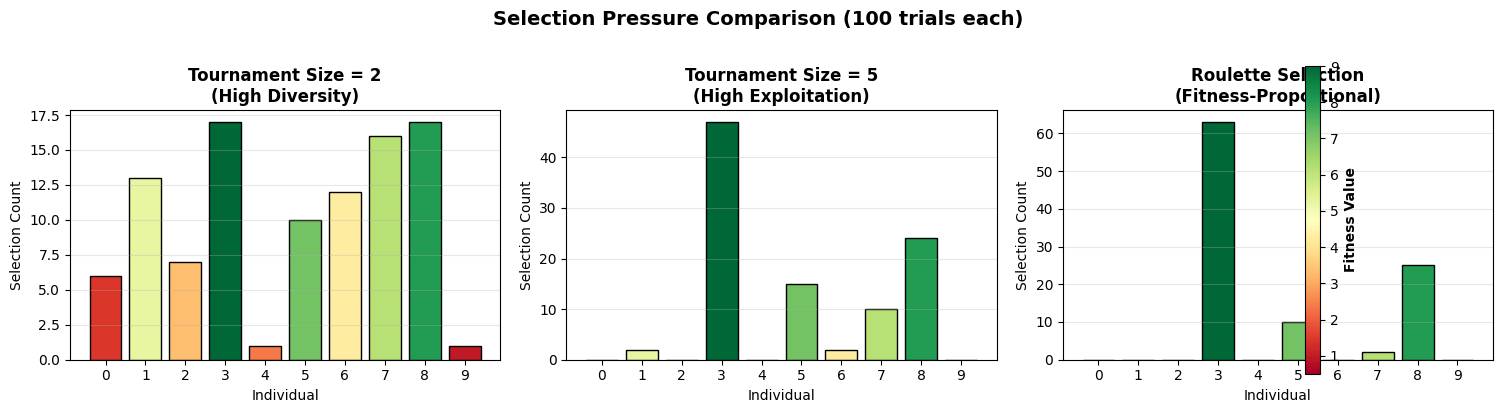

Selection Pressure Analysis:

Tournament Size 2 (diversity):
  Most selected: individual 3 (17 times)
  Least selected: individual 4 (1 times)
  Pressure ratio: 8.50x

Tournament Size 5 (exploitation):
  Most selected: individual 3 (47 times)
  Least selected: individual 0 (0 times)
  Pressure ratio: 47.00x

Roulette Selection (fitness-proportional):
  Most selected: individual 3 (63 times)
  Least selected: individual 0 (0 times)
  Pressure ratio: 63.00x

✓ Observation: Larger tournaments and roulette heavily favor high-fitness individuals


In [9]:
# Example 3: Selection Pressure Comparison — Visualization
"""
Compares selection methods and selection pressures.
Shows which individuals are selected by each operator.
"""

def simulate_roulette_selection(
    key: jnp.ndarray,
    fitness: jnp.ndarray,
    num_selections: int,
    temperature: float = 1.0,
    num_keys_per_atomic_op: int = 1,
) -> jnp.ndarray:
    """
    Simulate roulette (fitness-proportional) selection.
    Returns parent indices via softmax-sampled categorical distribution.
    """
    num_keys = num_keys_per_atomic_op
    keys = jr.split(key, num_keys)
    rng = keys[0] if keys.ndim > 0 else keys

    # Softmax transformation
    logits = fitness / temperature
    probs = jax.nn.softmax(logits)

    # Categorical sampling
    indices = jr.choice(
        rng, len(fitness), shape=(num_selections,), p=probs
    )

    return indices

# Setup: 10-individual population, select many times to show distribution
pop_size = 10
num_representatives = 100  # How many times each selection operator runs
key = jr.PRNGKey(456)

fitness = jnp.array(
    [1.0, 5.0, 3.0, 9.0, 2.0, 7.0, 4.0, 6.0, 8.0, 0.5]
)

# Run each selector multiple times
keys = jr.split(key, 3 * num_representatives)
key_idx = 0

counts_t2 = jnp.zeros(pop_size, dtype=jnp.int32)
counts_t5 = jnp.zeros(pop_size, dtype=jnp.int32)
counts_roulette = jnp.zeros(pop_size, dtype=jnp.int32)

for i in range(num_representatives):
    idx_t2 = simulate_tournament_selection(
        keys[key_idx], fitness, num_selections=1, tournament_size=2
    )
    idx_t2_scalar = jnp.asarray(idx_t2).item()
    counts_t2 = counts_t2.at[idx_t2_scalar].add(1)
    key_idx += 1

    idx_t5 = simulate_tournament_selection(
        keys[key_idx], fitness, num_selections=1, tournament_size=5
    )
    idx_t5_scalar = jnp.asarray(idx_t5).item()
    counts_t5 = counts_t5.at[idx_t5_scalar].add(1)
    key_idx += 1

    idx_roulette = simulate_roulette_selection(
        keys[key_idx], fitness, num_selections=1, temperature=1.0
    )
    idx_roulette_scalar = jnp.asarray(idx_roulette).item()
    counts_roulette = counts_roulette.at[idx_roulette_scalar].add(1)
    key_idx += 1

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

individuals = np.arange(pop_size)
colors_base = plt.cm.RdYlGn(fitness / fitness.max())

# Tournament Size 2
ax = axes[0]
ax.bar(individuals, counts_t2, color=colors_base, edgecolor='black')
ax.set_title('Tournament Size = 2\n(High Diversity)', fontsize=12, fontweight='bold')
ax.set_xlabel('Individual')
ax.set_ylabel('Selection Count')
ax.set_xticks(individuals)
ax.grid(axis='y', alpha=0.3)

# Tournament Size 5
ax = axes[1]
ax.bar(individuals, counts_t5, color=colors_base, edgecolor='black')
ax.set_title('Tournament Size = 5\n(High Exploitation)', fontsize=12, fontweight='bold')
ax.set_xlabel('Individual')
ax.set_ylabel('Selection Count')
ax.set_xticks(individuals)
ax.grid(axis='y', alpha=0.3)

# Roulette
ax = axes[2]
ax.bar(individuals, counts_roulette, color=colors_base, edgecolor='black')
ax.set_title('Roulette Selection\n(Fitness-Proportional)', fontsize=12, fontweight='bold')
ax.set_xlabel('Individual')
ax.set_ylabel('Selection Count')
ax.set_xticks(individuals)
ax.grid(axis='y', alpha=0.3)

# Add colorbar showing fitness gradient
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.RdYlGn, norm=plt.Normalize(vmin=fitness.min(), vmax=fitness.max())
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', pad=0.02, fraction=0.046)
cbar.set_label('Fitness Value', fontweight='bold')

plt.suptitle(
    'Selection Pressure Comparison (100 trials each)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print("Selection Pressure Analysis:")
print("\nTournament Size 2 (diversity):")
print(f"  Most selected: individual {jnp.argmax(counts_t2)} "
      f"({int(counts_t2.max())} times)")
print(f"  Least selected: individual {jnp.argmin(counts_t2)} "
      f"({int(counts_t2.min())} times)")
print(f"  Pressure ratio: {counts_t2.max() / (counts_t2.min() + 1):.2f}x")

print("\nTournament Size 5 (exploitation):")
print(f"  Most selected: individual {jnp.argmax(counts_t5)} "
      f"({int(counts_t5.max())} times)")
print(f"  Least selected: individual {jnp.argmin(counts_t5)} "
      f"({int(counts_t5.min())} times)")
print(f"  Pressure ratio: {counts_t5.max() / (counts_t5.min() + 1):.2f}x")

print("\nRoulette Selection (fitness-proportional):")
print(f"  Most selected: individual {jnp.argmax(counts_roulette)} "
      f"({int(counts_roulette.max())} times)")
print(f"  Least selected: individual {jnp.argmin(counts_roulette)} "
      f"({int(counts_roulette.min())} times)")
print(f"  Pressure ratio: {counts_roulette.max() / (counts_roulette.min() + 1):.2f}x")

print("\n✓ Observation: Larger tournaments and roulette heavily favor high-fitness individuals")

## Elite Pool Selection — Fusion Optimization

ElitePoolSelection demonstrates a key optimization: fusing parent selection and elite identification into a single O(N) pass.

**When elitism is enabled:**
- **Standard approach** (Tournament, Roulette): Parent selection O(X) + separate elite identification O(N) = O(X + N)
- **ElitePoolSelection approach**: Fuses both into single `argpartition` = O(N)

This is particularly valuable for large populations where the separate pass becomes noticeable.

In [10]:
# Example 4: PRNG Key Budgeting
"""
Demonstrates static PRNG budgeting for selection.
Key insight: selection uses constant-time budgeting (not population-scaled).
"""

print("PRNG Key Budgeting for Selection Operators\n")
print("Key Budget Formula:")
print("  num_keys_per_atomic_operation = 1 (stochastic) or 0 (deterministic)")
print("  total_keys_needed = num_keys_per_atomic_operation")
print("  (NOT scaled by population size or num_selections)\n")

# Example budgets
budget_data = [
    ("TournamentSelection", 1, "Stochastic"),
    ("RouletteSelection", 1, "Stochastic"),
    ("ElitePoolSelection", 1, "Stochastic"),
    ("BestSelection (deterministic)", 0, "Deterministic"),
]

print("Operator Key Budgets:")
for op_name, budget, dtype in budget_data:
    print(f"  {op_name:35} → {budget} key ({dtype})")

print("\nComparison with Crossover/Mutation:")
print("  Crossover: num_keys = num_pairs × num_offspring × num_keys_per_atomic_op")
print("  Mutation:  num_keys = pop_size × num_offspring × num_keys_per_atomic_op")
print("  Selection: num_keys = num_keys_per_atomic_op (constant!)\n")

# Concrete example
pop_size = 100
num_selections = 50

print(f"Example Population: pop_size={pop_size}, num_selections={num_selections}\n")
print("Key Allocations:")

crossover_keys = 50 * 2 * 1  # 50 pairs × 2 offspring × 1 key
print(f"  Crossover (50 pairs):  {crossover_keys} keys")

mutation_keys = pop_size * 1 * 1  # 100 × 1 offspring × 1 key
print(f"  Mutation (100 indiv):  {mutation_keys} keys")

selection_keys = 1
print(f"  Selection:             {selection_keys} key (constant!)")

total = crossover_keys + mutation_keys + selection_keys
selection_fraction = 100 * selection_keys / total
print(f"\n  Total keys needed:     {total}")
print(f"  Selection fraction:    {selection_fraction:.1f}%")

print("\n✓ Key Insight: Selection overhead is negligible vs \n  crossover/mutation (constant vs population-scaled)")

PRNG Key Budgeting for Selection Operators

Key Budget Formula:
  num_keys_per_atomic_operation = 1 (stochastic) or 0 (deterministic)
  total_keys_needed = num_keys_per_atomic_operation
  (NOT scaled by population size or num_selections)

Operator Key Budgets:
  TournamentSelection                 → 1 key (Stochastic)
  RouletteSelection                   → 1 key (Stochastic)
  ElitePoolSelection                  → 1 key (Stochastic)
  BestSelection (deterministic)       → 0 key (Deterministic)

Comparison with Crossover/Mutation:
  Crossover: num_keys = num_pairs × num_offspring × num_keys_per_atomic_op
  Mutation:  num_keys = pop_size × num_offspring × num_keys_per_atomic_op
  Selection: num_keys = num_keys_per_atomic_op (constant!)

Example Population: pop_size=100, num_selections=50

Key Allocations:
  Crossover (50 pairs):  100 keys
  Mutation (100 indiv):  100 keys
  Selection:             1 key (constant!)

  Total keys needed:     201
  Selection fraction:    0.5%

✓ Key Insigh

## Summary

**Key Takeaways:**

1. **Dual Output**: Selection returns both parent indices (for variation) and elite indices (for preservation)
2. **Static RNG Budgeting**: Constant-time key allocation enables efficient vectorization and JIT compilation
3. **Selection Pressure**: Tunable via tournament size, temperature, or elite pool size—critical for balancing exploration/exploitation
4. **Elite Preservation**: Immutable `.set_n_elites()` call freezes elite count; guaranteed top-k individuals in next generation
5. **Operator Choice**: Tournament (general), Roulette (fitness-weighted), ElitePool (high pressure)
6. **Performance**: ElitePoolSelection fuses elite identification for better scaling with elitism

**Best Practices:**
- Use TournamentSelection (tournament_size=3) as default
- Tune selection pressure across evolution phases (explore early, exploit late)
- Enable elitism (1-2% of population) to prevent convergence loss
- Monitor diversity metrics to catch premature convergence
- For fitness-weighted problems with guaranteed non-negative fitness, try RouletteSelection